In [1]:
# from numba import jit
import dask as da
import dask.distributed as dd
import scipy.special as ss
import scipy.spatial as spat
import scipy as sp
import numpy as np
import math as ma
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cartopy.crs as ccrs
import cartopy.feature as cf
from scipy.ndimage import convolve
from dask.array.core import map_blocks
import xarray as xr
from timeit import default_timer as timer
from typing import Union
import time
import multiprocessing
import random
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


if __name__ == '__main__':
    cluster = dd.LocalCluster(n_workers=int(multiprocessing.cpu_count()/2-2), threads_per_worker=2)
    print(cluster.dashboard_link)
    client = dd.Client(cluster)

2022-06-15 13:04:03,429 - distributed.diskutils - INFO - Found stale lock file and directory '/Users/akootz/Projects/geocat-internal-testing/akootz/dask-worker-space/worker-4iudhoh_', purging
2022-06-15 13:04:03,430 - distributed.diskutils - INFO - Found stale lock file and directory '/Users/akootz/Projects/geocat-internal-testing/akootz/dask-worker-space/worker-nv3y5rld', purging
2022-06-15 13:04:03,431 - distributed.diskutils - INFO - Found stale lock file and directory '/Users/akootz/Projects/geocat-internal-testing/akootz/dask-worker-space/worker-qy3jh16e', purging
2022-06-15 13:04:03,433 - distributed.diskutils - INFO - Found stale lock file and directory '/Users/akootz/Projects/geocat-internal-testing/akootz/dask-worker-space/worker-yansrnd8', purging
2022-06-15 13:04:03,434 - distributed.diskutils - INFO - Found stale lock file and directory '/Users/akootz/Projects/geocat-internal-testing/akootz/dask-worker-space/worker-91wt7w37', purging
2022-06-15 13:04:03,436 - distributed.di

http://127.0.0.1:8787/status


## Setup

In [24]:
start = time.perf_counter()
max_harm = 23
num_phi = 360
num_theta = 720
chunk_size = 256

theta = np.linspace(0, ma.tau - ma.tau / num_theta, num_theta)
phi = np.linspace(ma.pi / (2 * num_phi), ma.pi - ma.pi / (2 * num_phi), num_phi)
theta, phi = np.meshgrid(theta, phi)
scale = np.sin(phi)

mlist = []
nlist = []
harm_data = []
for nvalue in range(max_harm + 1):
    for mvalue in range(nvalue + 1):
        mlist.append(mvalue)
        nlist.append(nvalue)
        if round(random.random())==1 and mvalue!=0:
            harm_data.append(1j*round((random.random()*2-1))/(nvalue+1)**0)
        else:
            harm_data.append(1*round((random.random()*2-1))/(nvalue+1)**0)

harm_data = np.array(harm_data)
m = np.array(mlist)
n = np.array(nlist)


harm_data = xr.DataArray(harm_data, dims=['har']).chunk(chunk_size)
m = xr.DataArray(m, dims=['har']).chunk((chunk_size))
n = xr.DataArray(n, dims=['har']).chunk((chunk_size))

theta = xr.DataArray(theta, dims=['lat','lon']).chunk((chunk_size))
phi = xr.DataArray(phi, dims=['lat','lon']).chunk((chunk_size))
scale = xr.DataArray(scale, dims=['lat','lon']).chunk((chunk_size))

spat_data = np.sum(np.multiply(ss.sph_harm(m, n, theta, phi).real, harm_data.real),
                     axis=(0)) + np.sum(np.multiply(
                         ss.sph_harm(m, n, theta, phi).imag, harm_data.imag),
                                        axis=(0))

harmonics_np = np.array([[m,n] for n,m in zip(mlist,nlist)])
harmonics_xr = xr.DataArray(harmonics_np, dims=['har', 'm,n']).chunk((chunk_size)).compute()
spat_data_np = spat_data.values
spat_data_xr = xr.DataArray(spat_data_np, dims=['lat', 'lon']).chunk((chunk_size)).compute()
harm_data_np = harm_data.values
harm_data_xr = xr.DataArray(harm_data_np, dims=['har']).chunk((chunk_size)).compute()


theta_np = theta.values
theta_xr = xr.DataArray(theta_np, dims=['lat','lon']).chunk((chunk_size)).compute()
phi_np = phi.values
phi_xr = xr.DataArray(phi_np, dims=['lat', 'lon']).chunk((chunk_size)).compute()
scale_np = scale.values
scale_xr = xr.DataArray(scale_np, dims=['lat', 'lon']).chunk((chunk_size)).compute()

end = time.perf_counter()
print(end - start)

4.984555582050234


## The functions

In [17]:
from typing import Union

import numpy as np
import scipy.special as sspecial
import scipy.spatial as sspatial
import xarray as xr

SupportedTypes = Union[np.ndarray, xr.DataArray]
default_max_harm = 23  # 300 harmonics from 0,0 to 23,23


def decomposition(
    data: SupportedTypes,
    scale: SupportedTypes,
    theta: SupportedTypes,
    phi: SupportedTypes,
    max_harm: int = default_max_harm,
    chunk_size: int = 'auto',
) -> SupportedTypes:
    """Calculate the spherical harmonics of a dataset.

    Parameters
    ----------
    data : :class:`numpy.ndarray`, :class:`xarray.DataArray`
        2-dimensional dataset

    scale : :class:`numpy.ndarray`, :class:`xarray.DataArray`
        2-dimensional array containing the weighting of each point in the data.
        This is usually the area of the voronoi cell centered on the corresponding datapoint.
        the geocat.comp.spherical.scale_voronoi(theta,phi) function can provide a scale array.

    theta : :class:`numpy.ndarray`, :class:`xarray.DataArray`
        2-dimensional array containing the theta (longitude in radians) values for each datapoint in data.

    phi : :class:`numpy.ndarray`, :class:`xarray.DataArray`
        2-dimensional array containing the theta (latitude in radians) values for each datapoint in data.
        Phi is zero at the top of the sphere and pi at the bottom, phi = (lat_degrees-90)*(-1)*pi/180

    max_harm: :class: `int`, Optional
        The maximum harmonic value for both m and n.
        The total of harmonics calculated is (max_harm+1)*(max_harm+2)/2
        Defaults to 23, for 300 total harmonics.

    chunk_size: :class: `int`, Optional
        The size of the each edge of the dask chunks if using xarray.DataArray inputs.
        Some arrays will be 2d, and others 1d, and the final calculation operates on a 3d array.
        thus the chunks used in the largest calculation scale at chunk_size^3
        A chunk size of 256 is reccomended. Defaults to 'auto'

    Returns
    -------
    decomposition : :class:`numpy.ndarray`, :class:`xarray.DataArray`
        the spherical harmonic decomposition of the input data
    """

    scale_val = 1 / (np.sum(scale, axis=(0, 1)) *
                     sspecial.sph_harm(0, 0, 0, 0)**2)

    mlist = []
    nlist = []
    scale_mul = []
    for nvalue in range(max_harm + 1):
        for mvalue in range(nvalue + 1):
            mlist.append(mvalue)
            nlist.append(nvalue)
            if mvalue == 0:
                scale_mul.append(1)
            else:
                scale_mul.append(2)
    m = np.array(mlist)
    n = np.array(nlist)
    scale_mul = np.array(scale_mul)

    # if numpy, change dimensions to allow for broadcast in ss.sph_harm
    if type(data) is np.ndarray:
        m = np.expand_dims(m, axis=(0, 1))
        n = np.expand_dims(n, axis=(0, 1))
        theta = np.expand_dims(theta, axis=(2))
        phi = np.expand_dims(phi, axis=(2))
        scale_res = scale_mul * scale_val
        scale_dat = np.expand_dims(np.multiply(data, scale), axis=(2))

    # if xarray, set dims and chunks for broadcast in ss.sphere_harm
    if type(data) is xr.DataArray:
        m = xr.DataArray(m, dims=['har']).chunk((chunk_size))
        n = xr.DataArray(n, dims=['har']).chunk((chunk_size))
        scale_res = xr.DataArray(
            scale_mul,
            dims=['har'],
        ).chunk((chunk_size)) * scale_val
        scale_dat = xr.DataArray(
            np.multiply(data, scale),
            dims=data.dims,
        ).chunk((chunk_size))
        theta = xr.DataArray(theta, dims=data.dims).chunk((chunk_size))
        phi = xr.DataArray(phi, dims=data.dims).chunk((chunk_size))

    results = np.sum(
        np.multiply(scale_dat, sspecial.sph_harm(m, n, theta, phi)),
        axis=(0, 1),
    ) * scale_res
    return results


def recomposition(
    data: SupportedTypes,
    theta: SupportedTypes,
    phi: SupportedTypes,
    max_harm: int = default_max_harm,
    chunk_size: int = 'auto',
) -> SupportedTypes:
    """Calculate a dataset from spherical harmonics.

    Parameters
    ----------
    data : :class:`numpy.ndarray`, :class:`xarray.DataArray`
        1-dimensional array of spherical harmonics.
        These must by in the same order output by geocat.comp.spherical.decomposition.

    theta : :class:`numpy.ndarray`, :class:`xarray.DataArray`
        2-dimensional array containing the theta (longitude in radians) values for each datapoint in data.

    phi : :class:`numpy.ndarray`, :class:`xarray.DataArray`
        2-dimensional array containing the theta (latitude in radians) values for each datapoint in data.
        Phi is zero at the top of the sphere and pi at the bottom, phi = (lat_degrees-90)*(-1)*pi/180

    max_harm: :class: `int`, Optional
        The maximum harmonic value for both m and n.
        The total of harmonics calculated is (max_harm+1)*(max_harm+2)/2
        The number of total harmonics must equal the number of harmoncs in the input data.
        Defaults to 23, for 300 total harmonics.

    chunk_size: :class: `int`, Optional
        The size of the each edge of the dask chunks if using xarray.DataArray inputs.
        Some arrays will be 2d, and others 1d, and the final calculation operates on a 3d array.
        thus the chunks used in the largest calculation scale at chunk_size^3
        A chunk size of 256 is reccomended. Defaults to 'auto'

    Returns
    -------
    recomposition : :class:`numpy.ndarray`, :class:`xarray.DataArray`
        the spherical harmonic recomposition of the input data
    """

    mlist = []
    nlist = []
    for nvalue in range(max_harm + 1):
        for mvalue in range(nvalue + 1):
            mlist.append(mvalue)
            nlist.append(nvalue)
    m = np.array(mlist)
    n = np.array(nlist)

    # if numpy, change dimensions to allow for broadcast in ss.sph_harm
    if type(data) is np.ndarray:
        m = np.expand_dims(m, axis=(1, 2))
        n = np.expand_dims(n, axis=(1, 2))
        data = np.expand_dims(data, axis=(1, 2))
        theta = np.expand_dims(theta, axis=(0))
        phi = np.expand_dims(phi, axis=(0))

    # if xarray, set dims and chunks for broadcast in ss.sphere_harm
    if type(data) is xr.DataArray:
        m = xr.DataArray(m, dims=['har']).chunk((chunk_size))
        n = xr.DataArray(n, dims=['har']).chunk((chunk_size))
        data = xr.DataArray(data, dims=['har']).chunk((chunk_size))
        theta = xr.DataArray(theta, dims=theta.dims).chunk((chunk_size))
        phi = xr.DataArray(phi, dims=phi.dims).chunk((chunk_size))

    results = np.sum(
        np.multiply(sspecial.sph_harm(m, n, theta, phi).real, data.real),
        axis=(0),
    ) + np.sum(
        np.multiply(sspecial.sph_harm(m, n, theta, phi).imag, data.imag),
        axis=(0),
    )

    return results.real


def scale_voronoi(
    theta: SupportedTypes,
    phi: SupportedTypes,
    chunk_size: int = 'auto',
) -> SupportedTypes:
    """Calculate the area weighting for dataset.

    Parameters
    ----------
    theta : :class:`numpy.ndarray`, :class:`xarray.DataArray`
        2-dimensional array containing the theta (longitude in radians) values for each datapoint in data.

    phi : :class:`numpy.ndarray`, :class:`xarray.DataArray`
        2-dimensional array containing the theta (latitude in radians) values for each datapoint in data.
        Phi is zero at the top of the sphere and pi at the bottom, phi = (lat_degrees-90)*(-1)*pi/180

    chunk_size: :class: `int`, Optional
        The size of the each edge of the dask chunks if using xarray.DataArray inputs.
        Some arrays will be 2d, and others 1d, and the final calculation operates on a 3d array.
        thus the chunks used in the largest calculation scale at chunk_size^3
        A chunk size of 256 is reccomended. Defaults to 'auto'

    Returns
    -------
    scale : :class:`numpy.ndarray`, :class:`xarray.DataArray`
        2-dimensional array containing the area of the spherical voronoi cell for each theta and phi pair.
    """

    if type(theta) is xr.DataArray:
        theta = theta.to_numpy()
        phi = phi.to_numpy()

    theta_1d = theta.reshape((theta.shape[0] * theta.shape[1],))
    phi_1d = phi.reshape((phi.shape[0] * phi.shape[1],))

    data_locs_3d = np.zeros((len(phi_1d), 3))
    data_locs_3d[:, 0] = np.sin(phi_1d) * np.sin(theta_1d)
    data_locs_3d[:, 1] = np.sin(phi_1d) * np.cos(theta_1d)
    data_locs_3d[:, 2] = np.cos(phi_1d)

    scale = np.array(
        sspatial.SphericalVoronoi(
            data_locs_3d,
            radius=1.0,
            center=np.array([0, 0, 0]),
        ).calculate_areas()).reshape(theta.shape)

    if type(theta) is xr.DataArray:
        scale = xr.DataArray(scale, dims=theta.dims).chunk(chunk_size)

    return scale



## Compute harmonic decomposition

In [30]:
start = time.perf_counter()
decomp = decomposition(spat_data_xr, scale_xr, theta_xr, phi_xr, max_harm=max_harm, chunk_size=chunk_size)

# decomp2 = decomposition(spat_data_xr, scale_voronoi(theta_xr, phi_xr), theta_xr, phi_xr, max_harm=max_harm, chunk_size=chunk_size)

end = time.perf_counter()
print(end - start)
# decomp2

0.04302089777775109


In [34]:
import graphviz
decomp.data.visualize()

ModuleNotFoundError: No module named 'graphviz'

In [19]:
start = time.perf_counter()
decomp = decomp.compute()
# decomp2 = decomp2.compute()
end = time.perf_counter()
print(end - start)

4.64388071000576


In [29]:
decomp.values.visualize()

AttributeError: 'numpy.ndarray' object has no attribute 'visualize'

## Plot

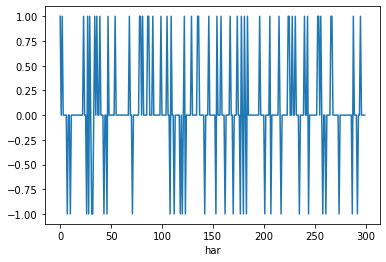

In [7]:
decomp.real.plot()
# decomp2.real.plot()

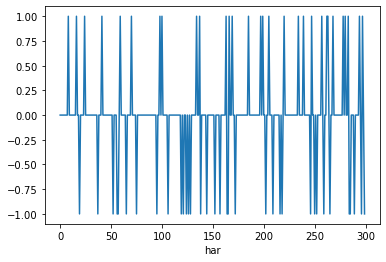

In [8]:
decomp.imag.plot()
# decomp2.imag.plot()

## Accuracy and precision

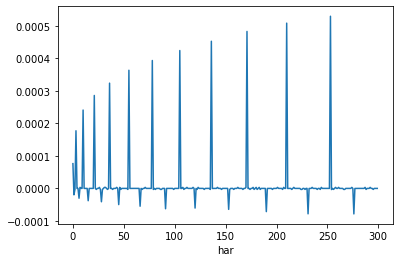

In [9]:
diff = (decomp-harm_data_xr)
diff.real.plot()
# diff2 = (decomp2-harm_data_xr)
# diff2.real.plot()
# (diff-diff2).real.plot()


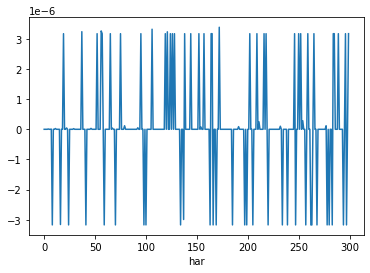

In [10]:
diff = (decomp-harm_data_xr)
diff.imag.plot()
# diff2 = (decomp2-harm_data_xr)
# diff2.imag.plot()
# (diff-diff2).real.plot()

## Compute harmonic recomposition

In [11]:
start = time.perf_counter()
recomp = recomposition(harm_data_xr, theta_xr, phi_xr, max_harm=max_harm, chunk_size=chunk_size)
end = time.perf_counter()
print(end - start)
recomp

0.022042157826945186


<xarray.DataArray (lat: 360, lon: 720)>
dask.array<real, shape=(360, 720), dtype=float64, chunksize=(256, 256), chunktype=numpy.ndarray>
Dimensions without coordinates: lat, lon

In [12]:
start = time.perf_counter()
recomp = recomp.compute()
end = time.perf_counter()
print(end - start)

4.303541653091088


In [13]:
diff = (recomp-spat_data_xr)

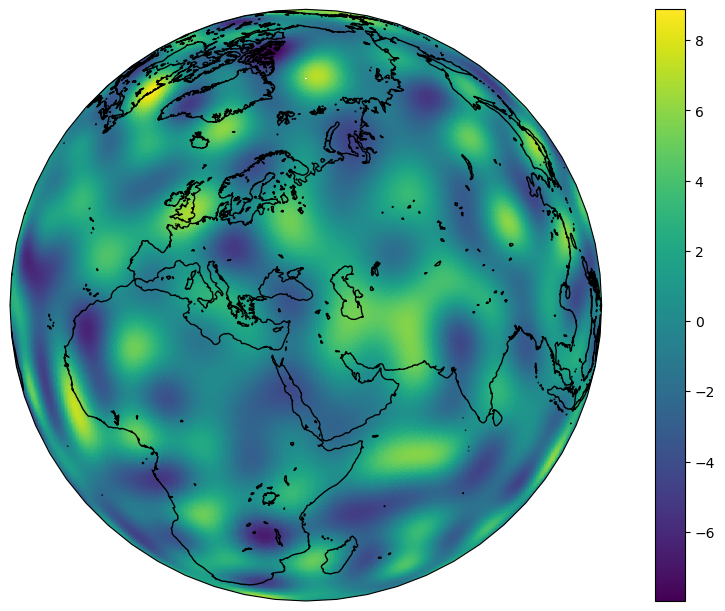

In [14]:
fig = plt.figure(dpi=100,figsize=(12,6),constrained_layout=True)
ax = plt.axes(projection=ccrs.Orthographic(40, 40))
ax.add_feature(cf.NaturalEarthFeature('physical', 'land', '50m'), edgecolor='black', facecolor='none', linewidth=1)
ax.add_feature(cf.NaturalEarthFeature('physical', 'lakes', '50m'), edgecolor='black', facecolor='none',linewidth=1)
# ax.add_feature(cf.NaturalEarthFeature('physical', 'rivers_lake_centerlines', '50m'),edgecolor='black', facecolor='none' )
plt.imshow(spat_data, interpolation='none',extent=[0,360,-90,90], origin='upper', transform=ccrs.PlateCarree())
plt.colorbar()
plt.show()

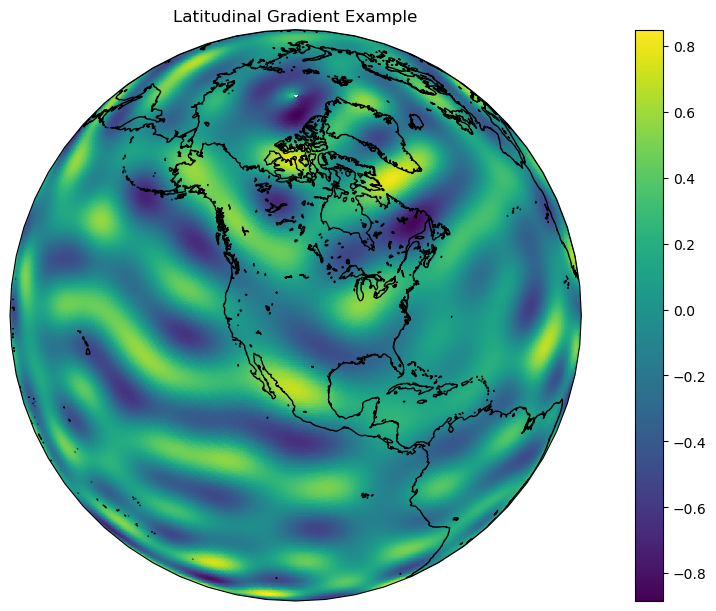

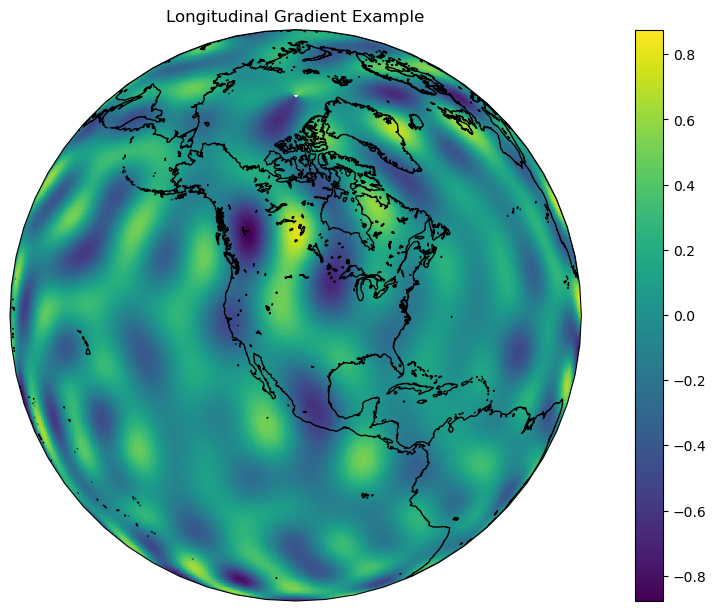

In [15]:
fig = plt.figure(dpi=100,figsize=(12,6),constrained_layout=True)
ax = plt.axes(projection=ccrs.Orthographic(-105, 40))
ax.add_feature(cf.NaturalEarthFeature('physical', 'land', '50m'), edgecolor='black', facecolor='none')
ax.add_feature(cf.NaturalEarthFeature('physical', 'lakes', '50m'), edgecolor='black', facecolor='none')
# ax.add_feature(cf.NaturalEarthFeature('physical', 'rivers_lake_centerlines', '50m'),edgecolor='black', facecolor='none' )
plt.imshow(np.gradient(recomp.real)[0], interpolation='none',extent=[0,360,-90,90], origin='upper', transform=ccrs.PlateCarree())
plt.colorbar()
plt.title('Latitudinal Gradient Example')
plt.show()

fig = plt.figure(dpi=100,figsize=(12,6),constrained_layout=True)
ax = plt.axes(projection=ccrs.Orthographic(-105, 40))
ax.add_feature(cf.NaturalEarthFeature('physical', 'land', '50m'), edgecolor='black', facecolor='none')
ax.add_feature(cf.NaturalEarthFeature('physical', 'lakes', '50m'), edgecolor='black', facecolor='none')
# ax.add_feature(cf.NaturalEarthFeature('physical', 'rivers_lake_centerlines', '50m'),edgecolor='black', facecolor='none' )
plt.imshow(np.gradient(recomp.real)[1]/scale_xr, interpolation='none',extent=[0,360,-90,90], origin='upper', transform=ccrs.PlateCarree())
plt.colorbar()
plt.title('Longitudinal Gradient Example')
plt.show()